# Weather Condition Classification from Outdoor Photographs
### MSML640 Final Project: Akhil Shekkari & Siddharth Pathania

**Task:** Five-class image classification (clear, cloudy, foggy, rainy, snowy)  
**Backbone:** EfficientNet-B0 (ImageNet pretrained, ~5.3 M parameters)  
**Experiment:** Four training configurations studied with ablation across augmentation and synthetic data.

In [1]:
import os, sys

# Mount Google Drive to load images (skip if you upload images another way)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted at /content/drive')
except ModuleNotFoundError:
    print('Not running in Colab, skipping Drive mount')

# Install dependencies
os.system('pip install timm torch torchvision seaborn scikit-learn tqdm diffusers transformers accelerate -q')
print('Setup done.')

Mounted at /content/drive
Drive mounted at /content/drive
Setup done.


In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

REPO_ROOT = Path('/content/drive/MyDrive/Computer_vision_final_project')
sys.path.insert(0, str(REPO_ROOT / 'src'))

DATA_ROOT = str(REPO_ROOT / 'data')
RESULTS_DIR = str(REPO_ROOT / 'results')
BACKBONE = 'efficientnet_b0'
EPOCHS = 5
BATCH_SIZE = 32

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Repo root: {REPO_ROOT}')

Device: cuda
Repo root: /content/drive/MyDrive/Computer_vision_final_project


In [3]:
# Kaggle setup -- reads credentials from kaggle_latest.json on Drive
import json, os, subprocess, sys
from pathlib import Path

with open('/content/drive/MyDrive/Computer_vision_final_project/kaggle_latest.json') as f:
    creds = json.load(f)

os.environ['KAGGLE_USERNAME'] = creds['username']
os.environ['KAGGLE_KEY'] = creds['key']
print('Kaggle configured')

# Download and organise the dataset into data/raw/
result = subprocess.run(
    [sys.executable, 'src/download_data.py'],
    capture_output=True, text=True, cwd=str(REPO_ROOT)
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)
# Show how many images landed in each class folder
print('\nImages in data/raw/:')
for cls in ['clear', 'cloudy', 'foggy', 'rainy', 'snowy']:
    d = REPO_ROOT / 'data' / 'raw' / cls
    n = len([f for f in d.iterdir() if f.suffix.lower() in {'.jpg','.jpeg','.png','.webp'}]) if d.exists() else 0
    print(f'  {cls}: {n}')


Kaggle configured
Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/weather-dataset
License(s): CC0-1.0

Copied 6011 images -> data/raw/

Next step: python src/prepare_data.py --data-root data


Images in data/raw/:
  clear: 1307
  cloudy: 0
  foggy: 692
  rainy: 1117
  snowy: 2895


In [4]:
# Download cloudy images from saurabhshahena/multi-class-weather-dataset
# Files are named cloudy001.jpg, shine50.jpg etc. -- filter by filename prefix
import subprocess, shutil
from pathlib import Path

tmp_cloudy = Path('/content/cloudy_tmp')
tmp_cloudy.mkdir(exist_ok=True)

result = subprocess.run(
    ['kaggle', 'datasets', 'download', '-d', 'saurabhshahane/multi-class-weather-dataset',
     '-p', str(tmp_cloudy), '--unzip'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

dst = REPO_ROOT / 'data' / 'raw' / 'cloudy'
dst.mkdir(parents=True, exist_ok=True)
copied = 0
for img in tmp_cloudy.rglob('*'):
    if img.stem.lower().startswith('cloudy') and img.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}:
        target = dst / img.name
        if not target.exists():
            shutil.copy2(img, target)
            copied += 1

print(f'Copied {copied} cloudy images -> {dst}')
shutil.rmtree(tmp_cloudy)

Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/multi-class-weather-dataset
License(s): Attribution 4.0 International (CC BY 4.0)


Copied 300 cloudy images -> /content/drive/MyDrive/Computer_vision_final_project/data/raw/cloudy


In [5]:
# Verify final image counts across all classes before running prepare_data
print('Images in data/raw/:')
for cls in ['clear', 'cloudy', 'foggy', 'rainy', 'snowy']:
    d = REPO_ROOT / 'data' / 'raw' / cls
    n = len([f for f in d.iterdir() if f.suffix.lower() in {'.jpg','.jpeg','.png','.webp'}]) if d.exists() else 0
    print(f'  {cls}: {n}')

Images in data/raw/:
  clear: 1307
  cloudy: 300
  foggy: 692
  rainy: 1117
  snowy: 2895


In [6]:
# Generate synthetic images with Stable Diffusion (configs 3 and 4 need these)
# Takes ~20-30 min on T4 GPU. Skip if already generated.
import subprocess, sys

result = subprocess.run(
    [sys.executable, 'src/synthesize.py', '--per-prompt', '5', '--steps', '30',
     '--output-dir', str(REPO_ROOT / 'data/synthetic')],
    capture_output=True, text=True, cwd=str(REPO_ROOT)
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Loading Stable Diffusion v1.5 on cuda (torch.float16) ...
  [clear] "outdoor scene with clear blue sky, photorealistic, bright sunlight, sh"
  [clear] "sunny day in a park, clear weather, photographic quality, blue sky"
  [clear] "clear sky suburban street, bright sunshine, photorealistic, no clouds"
  -> 15 images in /content/drive/MyDrive/Computer_vision_final_project/data/synthetic/clear
  [cloudy] "outdoor scene with overcast grey sky, photorealistic, diffuse light, n"
  [cloudy] "cloudy day in a city street, photographic quality, thick cloud cover"
  [cloudy] "suburban neighborhood under heavy cloud cover, photorealistic, grey sk"
  -> 15 images in /content/drive/MyDrive/Computer_vision_final_project/data/synthetic/cloudy
  [foggy] "rural highway in heavy fog at dusk, photographic, low contrast, misty "
  [foggy] "foggy forest path, dense mist, low visibility, photorealistic"
  [foggy] "city street in thick fog, photographic quality, low contrast, obscured"
  -> 15 images in /cont

## 1. Data Preparation

**Before running this notebook:**
1. Add seed-pool images to `data/raw/<class>/`
2. Add self-captured images to `data/captured/<class>/`
3. (Optional) Run `src/synthesize.py` to populate `data/synthetic/<class>/`
4. Run the cell below to create train / val / test split files.

In [7]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, 'src/prepare_data.py', '--data-root', DATA_ROOT],
    capture_output=True, text=True, cwd=str(REPO_ROOT)
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

train: 4490 images  {'clear': 929, 'cloudy': 225, 'foggy': 499, 'rainy': 796, 'snowy': 2041}
val  :  945 images  {'clear': 196, 'cloudy': 45, 'foggy': 103, 'rainy': 167, 'snowy': 434}
test :  951 images  {'clear': 197, 'cloudy': 45, 'foggy': 105, 'rainy': 169, 'snowy': 435}

Split files written to /content/drive/MyDrive/Computer_vision_final_project/data/splits/



### Class distribution

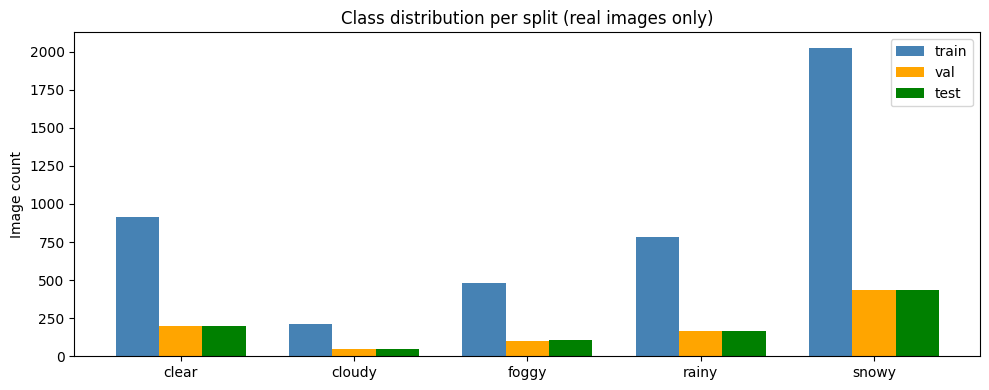

In [8]:
from collections import defaultdict

CLASSES = ['clear', 'cloudy', 'foggy', 'rainy', 'snowy']
splits = ['train', 'val', 'test']
counts = {}

for split in splits:
    p = Path(DATA_ROOT) / 'splits' / f'{split}.json'
    if not p.exists():
        continue
    with open(p) as f:
        entries = json.load(f)
    by_cls = defaultdict(int)
    for e in entries:
        if not e.get('synthetic', False):
            by_cls[e['label']] += 1
    counts[split] = [by_cls[c] for c in CLASSES]

x = np.arange(len(CLASSES))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 4))
for i, (split, clr) in enumerate(zip(splits, ['steelblue', 'orange', 'green'])):
    if split in counts:
        ax.bar(x + i * width, counts[split], width, label=split, color=clr)
ax.set_xticks(x + width); ax.set_xticklabels(CLASSES)
ax.set_ylabel('Image count'); ax.set_title('Class distribution per split (real images only)')
ax.legend(); plt.tight_layout(); plt.show()

## 2. Training: All Four Configurations

| Config | Data | Augmentation |
|--------|------|--------------|
| 1 | Our data only | None |
| 2 | Our data | Flip, crop, color jitter, rotation |
| 3 | Our data + Stable Diffusion | None |
| 4 | Our data + Stable Diffusion | Same as Config 2 |

In [9]:
from train import train
import argparse

def make_args(config):
    a = argparse.Namespace()
    a.config = config
    a.data_root = DATA_ROOT
    a.results_dir = RESULTS_DIR
    a.backbone = BACKBONE
    a.epochs = EPOCHS
    a.batch_size = BATCH_SIZE
    a.lr = 3e-4
    a.num_workers = 2
    return a

all_histories = {}
for cfg in [1, 2, 3, 4]:
    print(f'\nConfig {cfg}')
    history, best_val = train(make_args(cfg))
    all_histories[cfg] = history
    print(f'Config {cfg} done. Best val acc: {best_val:.4f}')


Config 1
Device: cuda
Config 1 (Baseline): 4415 train | 945 val


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch   1/5  train loss 1.4539 acc 0.737  val loss 1.3403 acc 0.840


Epoch   2/5  train loss 0.7868 acc 0.902  val loss 1.1032 acc 0.909


...

Epoch   1/5  train loss 1.4751 acc 0.724  val loss 1.4316 acc 0.813


Epoch   2/5  train loss 0.8690 acc 0.854  val loss 1.1262 acc 0.894


Epoch   3/5  train loss 0.7370 acc 0.925  val loss 1.0325 acc 0.928


Epoch   4/5  train loss 0.6988 acc 0.949  val loss 1.0136 acc 0.940


Epoch   5/5  train loss 0.6822 acc 0.955  val loss 1.0032 acc 0.940
Best val acc: 0.9397  |  results -> /content/drive/MyDrive/Computer_vision_final_project/results/config4
Config 4 done. Best val acc: 0.9397


## 3. Learning Curves: All Configs

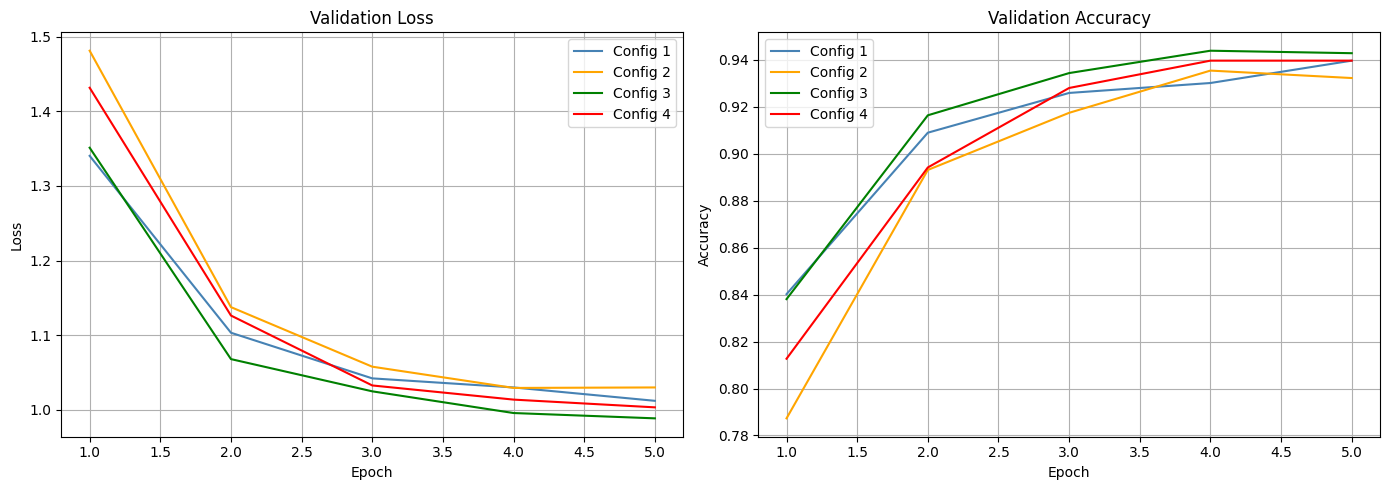

In [10]:
from utils import plot_all_val_curves

out = Path(RESULTS_DIR) / 'all_val_curves.png'
plot_all_val_curves(RESULTS_DIR, [1, 2, 3, 4], out)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'orange', 'green', 'red']
for cfg, clr in zip([1, 2, 3, 4], colors):
    if cfg not in all_histories:
        continue
    h = all_histories[cfg]
    ep = range(1, len(h['val_loss']) + 1)
    ax1.plot(ep, h['val_loss'], label=f'Config {cfg}', color=clr)
    ax2.plot(ep, h['val_acc'], label=f'Config {cfg}', color=clr)

for ax, title, ylabel in [
    (ax1, 'Validation Loss',     'Loss'),
    (ax2, 'Validation Accuracy', 'Accuracy'),
]:
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(True)

plt.tight_layout(); plt.show()

## 4. Test-Set Evaluation


Config 1 | epoch of best ckpt: 5 | best val acc: 0.9397 | test acc: 0.9422
              precision    recall  f1-score   support

       clear       0.96      0.94      0.95       197
      cloudy       0.66      1.00      0.80        45
       foggy       0.91      0.98      0.94       105
       rainy       0.94      0.91      0.92       169
       snowy       0.99      0.94      0.96       435

    accuracy                           0.94       951
   macro avg       0.89      0.95      0.92       951
weighted avg       0.95      0.94      0.94       951


Config 2 | epoch of best ckpt: 4 | best val acc: 0.9354 | test acc: 0.9180
              precision    recall  f1-score   support

       clear       0.98      0.94      0.96       197
      cloudy       0.50      0.98      0.66        45
       foggy       0.88      0.97      0.92       105
       rainy       0.93      0.91      0.92       169
       snowy       0.99      0.89      0.94       435

    accuracy                     

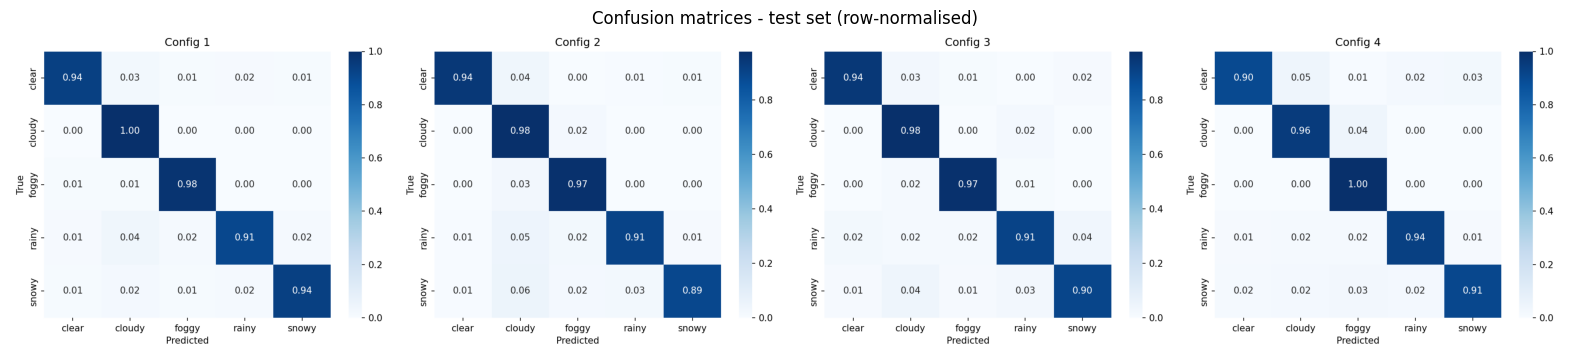

In [11]:
from evaluate import evaluate_config
from utils import compare_confusion_matrices
import matplotlib.image as mpimg

all_cms, done_cfgs = [], []
for cfg in [1, 2, 3, 4]:
    ckpt = Path(RESULTS_DIR) / f'config{cfg}' / 'best_model.pt'
    if not ckpt.exists():
        print(f'Config {cfg}: no checkpoint, skipping')
        continue
    cm, report = evaluate_config(cfg, DATA_ROOT, RESULTS_DIR, BACKBONE, BATCH_SIZE)
    all_cms.append(cm)
    done_cfgs.append(cfg)

if len(all_cms) > 1:
    cmp_path = Path(RESULTS_DIR) / 'confusion_matrix_comparison.png'
    compare_confusion_matrices(all_cms, [f'Config {c}' for c in done_cfgs], CLASSES, cmp_path)
    img = mpimg.imread(cmp_path)
    plt.figure(figsize=(20, 5)); plt.imshow(img); plt.axis('off')
    plt.title('Confusion matrices - test set (row-normalised)'); plt.show()

## 5. Robustness Suite

Four synthetic perturbations are applied to the clean test set and accuracy is measured per-config.

In [12]:
from robustness import run_robustness_suite
import argparse

rob_args = argparse.Namespace(
    configs=done_cfgs,
    data_root=DATA_ROOT,
    results_dir=RESULTS_DIR,
    backbone=BACKBONE,
    batch_size=BATCH_SIZE,
)
rob_results = run_robustness_suite(rob_args)

Config 1 | gaussian_blur            : 0.6151
Config 1 | brightness_reduction     : 0.8875
Config 1 | rectangular_occlusion    : 0.9232
Config 1 | gaussian_noise           : 0.2271
Config 2 | gaussian_blur            : 0.4238
Config 2 | brightness_reduction     : 0.8654
Config 2 | rectangular_occlusion    : 0.9159
Config 2 | gaussian_noise           : 0.4154
Config 3 | gaussian_blur            : 0.6193
Config 3 | brightness_reduction     : 0.8591
Config 3 | rectangular_occlusion    : 0.9222
Config 3 | gaussian_noise           : 0.2419
Config 4 | gaussian_blur            : 0.3470
Config 4 | brightness_reduction     : 0.8707
Config 4 | rectangular_occlusion    : 0.9348
Config 4 | gaussian_noise           : 0.2639

Robustness results -> /content/drive/MyDrive/Computer_vision_final_project/results/robustness_results.json


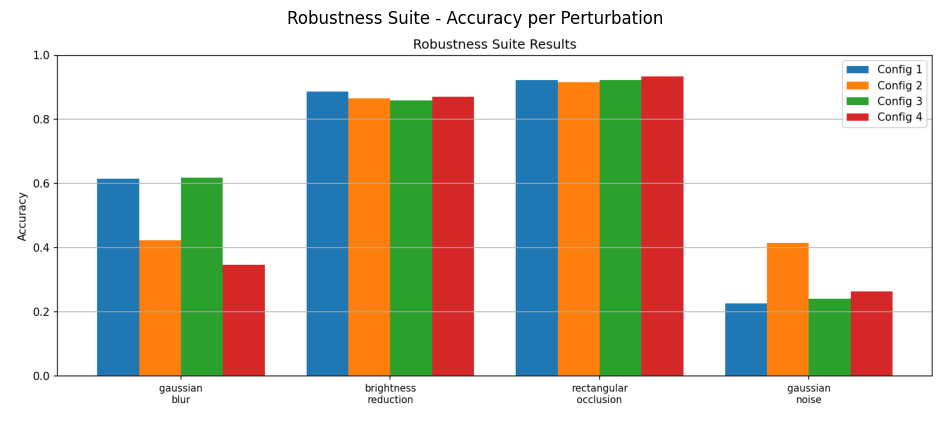

In [13]:
import matplotlib.image as mpimg
rob_plot = Path(RESULTS_DIR) / 'robustness_plot.png'
if rob_plot.exists():
    img = mpimg.imread(rob_plot)
    plt.figure(figsize=(12, 5)); plt.imshow(img); plt.axis('off')
    plt.title('Robustness Suite - Accuracy per Perturbation'); plt.show()

## 6. Per-class Error Analysis

Which classes are hardest to classify, and which misclassification pairs are most common?

In [14]:
import pandas as pd

rows = []
for cfg in done_cfgs:
    rp_path = Path(RESULTS_DIR) / f'config{cfg}' / 'classification_report.json'
    if not rp_path.exists():
        continue
    with open(rp_path) as f:
        rp = json.load(f)
    for cls in CLASSES:
        if cls in rp:
            rows.append({
                'Config': cfg,
                'Class': cls,
                'Precision': round(rp[cls]['precision'], 3),
                'Recall': round(rp[cls]['recall'], 3),
                'F1': round(rp[cls]['f1-score'], 3),
                'Support': rp[cls]['support'],
            })

df = pd.DataFrame(rows)
if not df.empty:
    pivot = df.pivot_table(index='Class', columns='Config', values='F1')
    print('F1-score per class across configs:')
    display(pivot.style.background_gradient(cmap='RdYlGn', axis=None))

F1-score per class across configs:


Config,1,2,3,4
Class,,,,
clear,0.951000,0.961000,0.947000,0.927000
cloudy,0.796000,0.662000,0.739000,0.782000
foggy,0.945000,0.923000,0.936000,0.921000
rainy,0.925000,0.916000,0.908000,0.933000
snowy,0.963000,0.938000,0.937000,0.946000


## 7. Summary & Hypothesis Assessment

**Central hypothesis:**  
> Augmentation will improve robustness most on perturbations that resemble the augmentation distribution (color jitter vs. overcast, blur vs. rain), while synthesis will help most on minority classes where real samples are scarce.

Fill in your observations below after running all experiments.

In [15]:
# Tabulate final test accuracy across configs
summary_rows = []
for cfg in done_cfgs:
    rp_path = Path(RESULTS_DIR) / f'config{cfg}' / 'classification_report.json'
    if rp_path.exists():
        with open(rp_path) as f:
            rp = json.load(f)
        summary_rows.append({'Config': cfg, 'Test Accuracy': round(rp['accuracy'], 4)})

if summary_rows:
    df_sum = pd.DataFrame(summary_rows).set_index('Config')
    display(df_sum.style.highlight_max(color='lightgreen'))

# Robustness delta: Config 2 vs Config 1 (augmentation effect on robustness)
if rob_results and 1 in done_cfgs and 2 in done_cfgs:
    print('\nRobustness delta (Config 2 - Config 1):')
    for pert, cfg_accs in rob_results.items():
        delta = cfg_accs.get(2, 0) - cfg_accs.get(1, 0)
        print(f'  {pert:<26}: {delta:+.4f}')

,Test Accuracy
Config,
1,0.942200
2,0.918000
3,0.921100
4,0.927400



Robustness delta (Config 2 - Config 1):
  gaussian_blur             : -0.1914
  brightness_reduction      : -0.0221
  rectangular_occlusion     : -0.0074
  gaussian_noise            : +0.1882


## 8. Demo: Classify a New Image

Drop any image into `data/demo/` on your Drive, then run the cell below.


Prediction for: /content/drive/MyDrive/Computer_vision_final_project/data/demo/Test_1.jpg
  clear    0.423  ################
  cloudy   0.265  ##########
  foggy    0.164  ######
  rainy    0.084  ###
  snowy    0.064  ##

Top prediction: clear


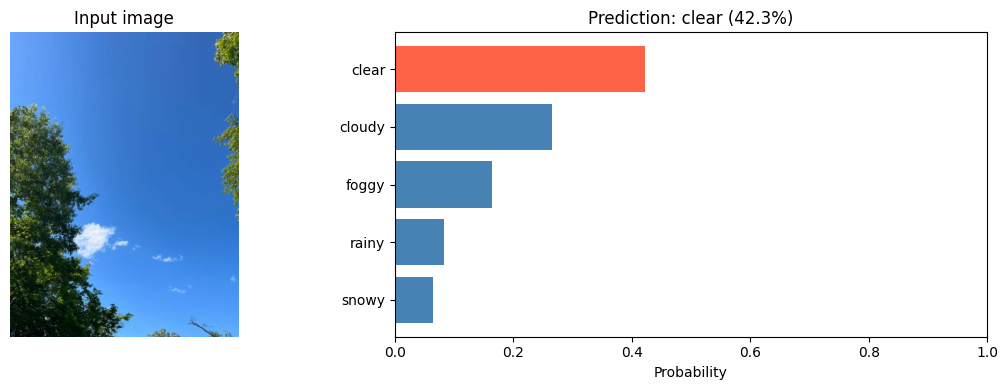

In [18]:
from predict import predict
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# set the image path and which config checkpoint to use
IMAGE_PATH = str(REPO_ROOT / 'data/demo/Test_1.jpg')  # change filename
CHECKPOINT = str(REPO_ROOT / 'results/config2/best_model.pt')

results = predict(IMAGE_PATH, CHECKPOINT, BACKBONE)
classes = [r[0] for r in results]
probs = [r[1] for r in results]

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))

img = mpimg.imread(IMAGE_PATH)
ax_img.imshow(img)
ax_img.axis('off')
ax_img.set_title(f'Input image')

colors = ['steelblue' if c != classes[0] else 'tomato' for c in classes]
ax_bar.barh(classes, probs, color=colors)
ax_bar.set_xlim(0, 1)
ax_bar.set_xlabel('Probability')
ax_bar.set_title(f'Prediction: {classes[0]} ({probs[0]:.1%})')
ax_bar.invert_yaxis()

plt.tight_layout()
plt.show()


Prediction for: /content/drive/MyDrive/Computer_vision_final_project/data/demo/test2.jpg
  rainy    0.367  ##############
  cloudy   0.255  ##########
  snowy    0.243  #########
  clear    0.107  ####
  foggy    0.028  #

Top prediction: rainy


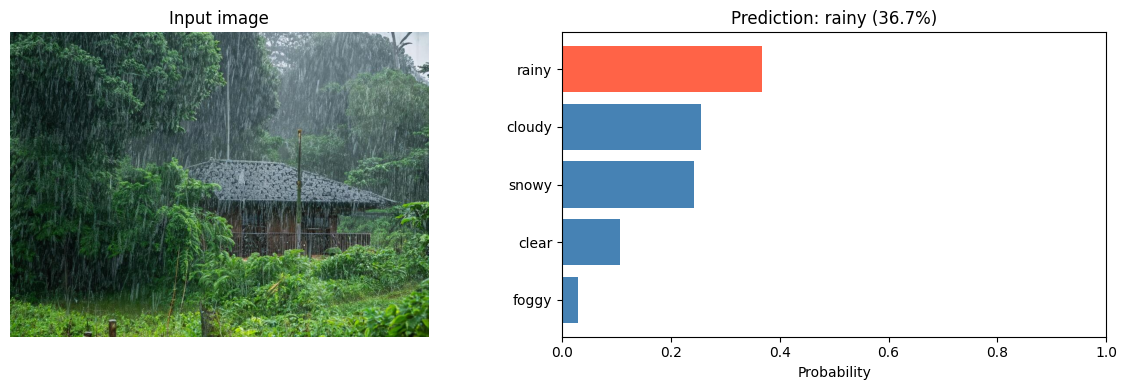

In [16]:
from predict import predict
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# set the image path and which config checkpoint to use
IMAGE_PATH = str(REPO_ROOT / 'data/demo/test2.jpg')  # change filename
CHECKPOINT = str(REPO_ROOT / 'results/config2/best_model.pt')

results = predict(IMAGE_PATH, CHECKPOINT, BACKBONE)
classes = [r[0] for r in results]
probs = [r[1] for r in results]

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))

img = mpimg.imread(IMAGE_PATH)
ax_img.imshow(img)
ax_img.axis('off')
ax_img.set_title(f'Input image')

colors = ['steelblue' if c != classes[0] else 'tomato' for c in classes]
ax_bar.barh(classes, probs, color=colors)
ax_bar.set_xlim(0, 1)
ax_bar.set_xlabel('Probability')
ax_bar.set_title(f'Prediction: {classes[0]} ({probs[0]:.1%})')
ax_bar.invert_yaxis()

plt.tight_layout()
plt.show()